# Multi-Asset Portfolio Risk & Volatility Forecasting
### Value-at-Risk, Expected Shortfall, drawdown analysis, and mean-variance optimization for a 5-asset allocation

**Domain:** Investment / Portfolio Risk Management &nbsp;|&nbsp;
**Tools:** Python (numpy, pandas, scipy.optimize, matplotlib, seaborn)

---

## Business Problem

An investment committee holds a 5-asset allocation (US Equities, Emerging Market Equities, Bonds, Gold, Bitcoin) and
needs a quantitative risk report before its next allocation review:

1. What is the portfolio's **risk-adjusted return profile** (Sharpe ratio, drawdown) versus each individual asset?
2. What is the **1-day and 10-day 95%/99% Value-at-Risk (VaR)** and **Expected Shortfall (CVaR)**?
3. Is the current allocation close to the **maximum-Sharpe** portfolio on the efficient frontier, or is there
   uncaptured diversification benefit?
4. How does portfolio risk change under a **correlation-shock stress scenario** (correlations rising toward 1 in a
   crisis, as they empirically do)?

> **Note on data:** Uses simulated daily returns (3 years, calibrated to realistic annualized return/volatility and
> cross-asset correlation for each asset class) rather than a scraped/licensed price feed, so the notebook is fully
> reproducible without external data dependencies. Swap the simulator for `yfinance`/Bloomberg pulls and the
> analysis pipeline is unchanged.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)
print("Environment ready.")

Environment ready.


## 1. Simulated Multi-Asset Return Series

Daily log returns are generated from a correlated multivariate normal process (Cholesky decomposition of a target
correlation matrix), calibrated so each asset's *annualized* return/volatility matches realistic historical ranges.

In [2]:
assets = ["US_Equities", "EM_Equities", "Bonds", "Gold", "Bitcoin"]
n_days = 756  # ~3 trading years

annual_return = np.array([0.09, 0.07, 0.03, 0.05, 0.35])
annual_vol    = np.array([0.16, 0.22, 0.06, 0.15, 0.65])

corr = np.array([
    [1.00, 0.75, -0.15, 0.05, 0.20],
    [0.75, 1.00, -0.10, 0.10, 0.25],
    [-0.15,-0.10, 1.00, 0.20, -0.05],
    [0.05, 0.10, 0.20, 1.00, 0.10],
    [0.20, 0.25, -0.05, 0.10, 1.00],
])

daily_mu = annual_return / 252
daily_vol = annual_vol / np.sqrt(252)
cov_matrix = np.outer(daily_vol, daily_vol) * corr
L = np.linalg.cholesky(cov_matrix)

z = rng.standard_normal((n_days, len(assets)))
daily_returns = daily_mu + z @ L.T

dates = pd.bdate_range("2023-01-02", periods=n_days)
returns = pd.DataFrame(daily_returns, index=dates, columns=assets)
prices = 100 * (1 + returns).cumprod()

print(f"Simulated {n_days} trading days across {len(assets)} assets.")
returns.head()

Simulated 756 trading days across 5 assets.


            US_Equities  EM_Equities     Bonds      Gold   Bitcoin
2023-01-02     0.000370     0.003029 -0.000885 -0.008255 -0.017464
2023-01-03    -0.009638    -0.009478  0.005693 -0.002103 -0.033795
2023-01-04     0.005294     0.008641  0.000261 -0.007592  0.003199
2023-01-05     0.007365    -0.004817 -0.002081 -0.019039 -0.058166
2023-01-06    -0.018206    -0.021020 -0.003589 -0.000882 -0.006840

## 2. Individual Asset Risk/Return Profile

In [3]:
summary = pd.DataFrame({
    "Ann. Return": returns.mean() * 252,
    "Ann. Volatility": returns.std() * np.sqrt(252),
    "Skew": returns.skew(),
    "Excess Kurtosis": returns.kurtosis(),
})
summary["Sharpe (rf=2%)"] = (summary["Ann. Return"] - 0.02) / summary["Ann. Volatility"]
summary.round(3)

             Ann. Return  Ann. Volatility  ...  Excess Kurtosis  Sharpe (rf=2%)
US_Equities       -0.084            0.157  ...            0.121          -0.662
EM_Equities       -0.009            0.227  ...           -0.146          -0.128
Bonds              0.019            0.060  ...           -0.129          -0.015
Gold              -0.068            0.148  ...           -0.015          -0.596
Bitcoin            0.153            0.634  ...           -0.297           0.210

[5 rows x 5 columns]

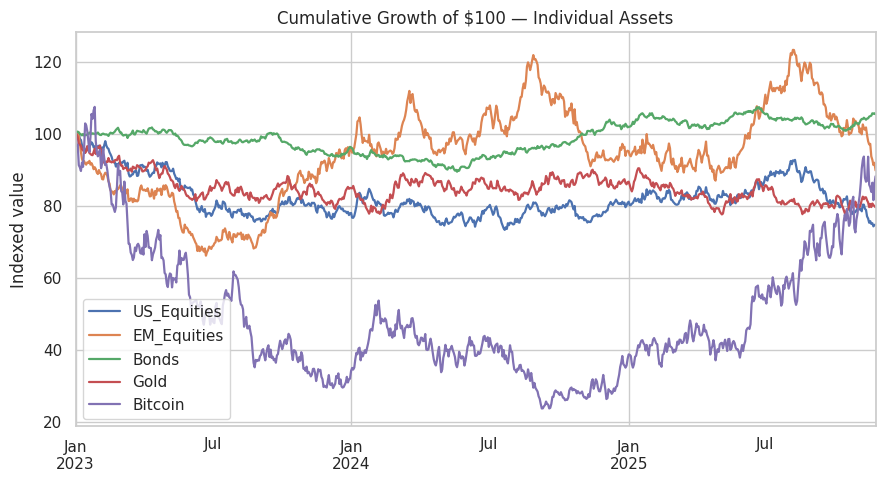

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
(prices / prices.iloc[0] * 100).plot(ax=ax, linewidth=1.6)
ax.set_title("Cumulative Growth of $100 — Individual Assets")
ax.set_ylabel("Indexed value")
plt.tight_layout()
plt.savefig("outputs/01_cumulative_growth.png")
plt.show()

## 3. Correlation Structure & Diversification

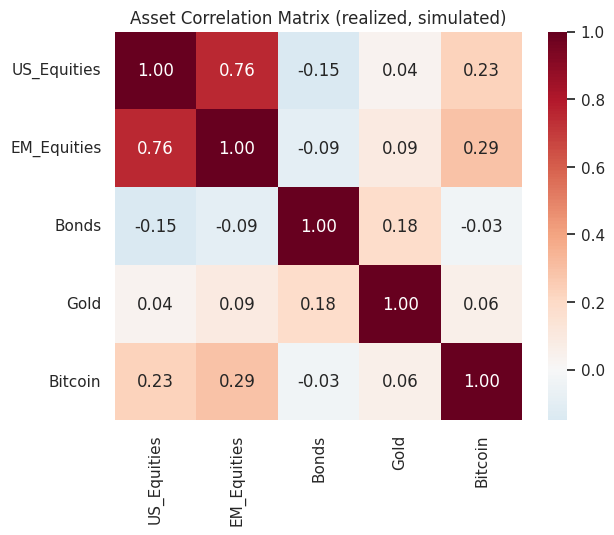

In [5]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Asset Correlation Matrix (realized, simulated)")
plt.tight_layout()
plt.savefig("outputs/02_correlation_matrix.png")
plt.show()

## 4. Mean-Variance Optimization: Efficient Frontier

We simulate 8,000 random long-only portfolios, then use `scipy.optimize` to solve exactly for the **maximum-Sharpe**
and **minimum-volatility** portfolios. Both are compared with an equal-weight (naive 1/N) allocation.

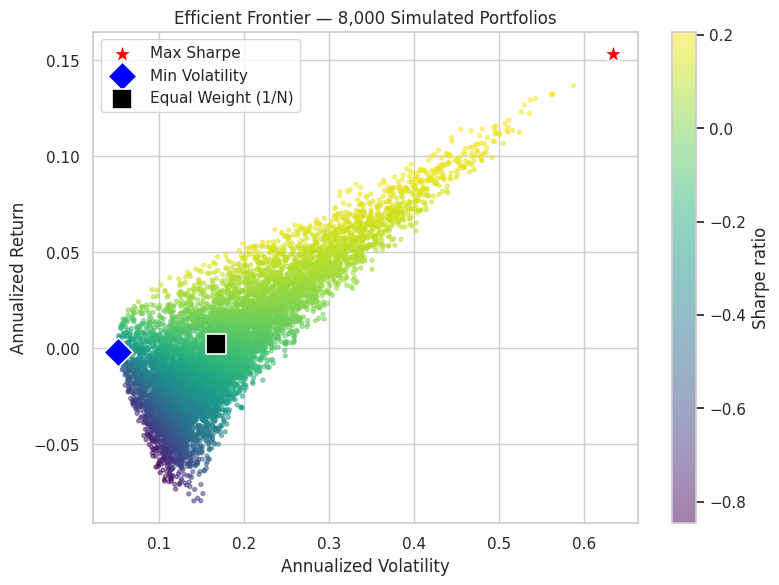

             Equal Weight  Max Sharpe (unconstrained)  Min Volatility
US_Equities           0.2                         0.0           0.152
EM_Equities           0.2                         0.0           0.000
Bonds                 0.2                         0.0           0.788
Gold                  0.2                         0.0           0.059
Bitcoin               0.2                         1.0           0.000

In [6]:
mean_ret = returns.mean().values * 252
cov_ann = returns.cov().values * 252
n = len(assets)
rf = 0.02

def port_stats(w):
    ret = w @ mean_ret
    vol = np.sqrt(w @ cov_ann @ w)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

# Monte Carlo cloud
n_sims = 8000
w_rand = rng.dirichlet(np.ones(n), size=n_sims)
rand_stats = np.array([port_stats(w) for w in w_rand])

# Exact optimization: max Sharpe
neg_sharpe = lambda w: -port_stats(w)[2]
constraints = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
bounds = tuple((0, 1) for _ in range(n))
res_sharpe = minimize(neg_sharpe, x0=np.ones(n)/n, bounds=bounds, constraints=constraints)
w_max_sharpe = res_sharpe.x

# Exact optimization: min volatility
vol_fn = lambda w: port_stats(w)[1]
res_minvol = minimize(vol_fn, x0=np.ones(n)/n, bounds=bounds, constraints=constraints)
w_min_vol = res_minvol.x

w_equal = np.ones(n) / n

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(rand_stats[:,1], rand_stats[:,0], c=rand_stats[:,2], cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Sharpe ratio")

for w, label, marker, color in [
    (w_max_sharpe, "Max Sharpe", "*", "red"),
    (w_min_vol, "Min Volatility", "D", "blue"),
    (w_equal, "Equal Weight (1/N)", "s", "black"),
]:
    r, v, s = port_stats(w)
    ax.scatter(v, r, marker=marker, color=color, s=220, edgecolor="white", linewidth=1.2, label=label, zorder=5)

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("Efficient Frontier — 8,000 Simulated Portfolios")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/03_efficient_frontier.png")
plt.show()

alloc_table = pd.DataFrame({"Equal Weight": w_equal, "Max Sharpe (unconstrained)": w_max_sharpe, "Min Volatility": w_min_vol},
                            index=assets).round(3)
alloc_table

In [7]:
for w, label in [(w_equal, "Equal Weight"), (w_max_sharpe, "Max Sharpe (unconstrained)"), (w_min_vol, "Min Volatility")]:
    r, v, s = port_stats(w)
    print(f"{label:28s} | Return: {r:6.2%} | Volatility: {v:6.2%} | Sharpe: {s:5.2f}")

Equal Weight                 | Return:  0.23% | Volatility: 16.76% | Sharpe: -0.11
Max Sharpe (unconstrained)   | Return: 15.32% | Volatility: 63.38% | Sharpe:  0.21
Min Volatility               | Return: -0.18% | Volatility:  5.20% | Sharpe: -0.42


**Important finding:** the unconstrained max-Sharpe optimizer allocates **100% to Bitcoin**, a classic quant-finance
pitfall. This is not a bug. It is the well-documented instability of naive mean-variance optimization ("Markowitz's
curse"). With only about three years of data, sample means carry substantial error, so the optimizer bets heavily on
whichever asset happened to realize the best historical Sharpe and ignores estimation uncertainty. A "100% Bitcoin"
recommendation would not be suitable for an investment committee. We therefore impose **position limits** that reflect
actual risk tolerance and acknowledge that trailing sample means may not repeat. The report uses a **35% single-asset
cap** for the remaining analysis.

In [8]:
cap = 0.35
bounds_capped = tuple((0, cap) for _ in range(n))
res_sharpe_capped = minimize(neg_sharpe, x0=np.ones(n)/n, bounds=bounds_capped, constraints=constraints)
w_max_sharpe_capped = res_sharpe_capped.x

alloc_table["Max Sharpe (35% cap)"] = w_max_sharpe_capped.round(3)
r,v,s = port_stats(w_max_sharpe_capped)
print(f"Max Sharpe (35% cap)         | Return: {r:6.2%} | Volatility: {v:6.2%} | Sharpe: {s:5.2f}")
alloc_table.round(3)

Max Sharpe (35% cap)         | Return:  5.76% | Volatility: 25.01% | Sharpe:  0.15


             Equal Weight  ...  Max Sharpe (35% cap)
US_Equities           0.2  ...                  0.00
EM_Equities           0.2  ...                  0.30
Bonds                 0.2  ...                  0.35
Gold                  0.2  ...                  0.00
Bitcoin               0.2  ...                  0.35

[5 rows x 4 columns]

In [9]:
# From here on, "the portfolio" under analysis is the capped max-Sharpe allocation —
# the realistic, committee-deployable one, not the unconstrained solver output.
w_max_sharpe = w_max_sharpe_capped

## 5. Value-at-Risk & Expected Shortfall

We compute 1-day 95%/99% VaR and CVaR (Expected Shortfall) for the **Max Sharpe** portfolio using three methods:
**historical simulation**, **parametric (variance-covariance, normal assumption)**, and **Monte Carlo**. Comparing methods
matters because a risk report should show where estimates agree and explain where they diverge.

In [10]:
port_daily_returns = returns.values @ w_max_sharpe
port_series = pd.Series(port_daily_returns, index=returns.index, name="portfolio_return")

def hist_var_cvar(rets, alpha):
    var = -np.percentile(rets, (1-alpha)*100)
    cvar = -rets[rets <= -var].mean()
    return var, cvar

def param_var_cvar(rets, alpha):
    from scipy.stats import norm
    mu, sigma = rets.mean(), rets.std()
    z = norm.ppf(1-alpha)
    var = -(mu + z*sigma)
    cvar = -(mu - sigma * norm.pdf(z) / (1-alpha))
    return var, cvar

def mc_var_cvar(mu, sigma, alpha, n=200000, seed=1):
    r = np.random.default_rng(seed).normal(mu, sigma, n)
    return hist_var_cvar(r, alpha)

rows = []
for alpha in [0.95, 0.99]:
    hv, hc = hist_var_cvar(port_daily_returns, alpha)
    pv, pc = param_var_cvar(port_daily_returns, alpha)
    mv, mc = mc_var_cvar(port_daily_returns.mean(), port_daily_returns.std(), alpha)
    rows.append({"confidence": alpha, "method": "Historical", "VaR_1d": hv, "CVaR_1d": hc})
    rows.append({"confidence": alpha, "method": "Parametric", "VaR_1d": pv, "CVaR_1d": pc})
    rows.append({"confidence": alpha, "method": "Monte Carlo", "VaR_1d": mv, "CVaR_1d": mc})

var_table = pd.DataFrame(rows)
var_table["VaR_10d"] = var_table["VaR_1d"] * np.sqrt(10)   # square-root-of-time scaling
var_table.round(4)

   confidence       method  VaR_1d  CVaR_1d  VaR_10d
0        0.95   Historical  0.0254   0.0317   0.0804
1        0.95   Parametric  0.0257   0.0322   0.0812
2        0.95  Monte Carlo  0.0256   0.0323   0.0810
3        0.99   Historical  0.0358   0.0376   0.1131
4        0.99   Parametric  0.0364   0.0417   0.1151
5        0.99  Monte Carlo  0.0367   0.0421   0.1159

In [11]:
port_value = 10_000_000  # $10M notional for dollar-risk framing
var_95 = var_table.query("confidence==0.95 and method=='Historical'")["VaR_1d"].iloc[0]
var_99 = var_table.query("confidence==0.99 and method=='Historical'")["VaR_1d"].iloc[0]
print(f"On a \${port_value:,.0f} allocation to the Max-Sharpe portfolio:")
print(f"  95% 1-day VaR  = \${var_95*port_value:,.0f}  (expect a loss this size or worse ~1 day in 20)")
print(f"  99% 1-day VaR  = \${var_99*port_value:,.0f}  (expect a loss this size or worse ~1 day in 100)")

On a \$10,000,000 allocation to the Max-Sharpe portfolio:
  95% 1-day VaR  = \$254,121  (expect a loss this size or worse ~1 day in 20)
  99% 1-day VaR  = \$357,781  (expect a loss this size or worse ~1 day in 100)


## 6. Rolling Volatility & EWMA (RiskMetrics) Forecast

Realized volatility clusters over time. We track 21-day rolling volatility and compare it with an
**exponentially-weighted moving average (EWMA, λ=0.94)** forecast. This industry-standard RiskMetrics approach shows
whether current risk is running above or below its recent trend.

Next-day EWMA volatility forecast (annualized): 27.59%
Trailing 21-day realized volatility (annualized): 28.22%


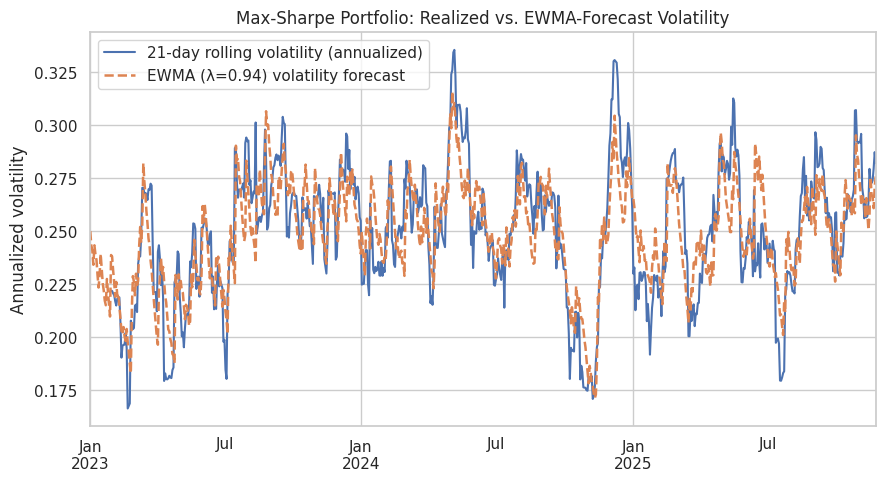

In [12]:
LAMBDA = 0.94
ewma_var = np.zeros(len(port_series))
ewma_var[0] = port_series.var()
for t in range(1, len(port_series)):
    ewma_var[t] = LAMBDA * ewma_var[t-1] + (1-LAMBDA) * port_series.iloc[t-1]**2
ewma_vol_annualized = np.sqrt(ewma_var) * np.sqrt(252)

rolling_vol_annualized = port_series.rolling(21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(9,5))
rolling_vol_annualized.plot(ax=ax, label="21-day rolling volatility (annualized)", linewidth=1.5)
pd.Series(ewma_vol_annualized, index=port_series.index).plot(
    ax=ax, label="EWMA (λ=0.94) volatility forecast", linewidth=1.8, linestyle="--")
ax.set_title("Max-Sharpe Portfolio: Realized vs. EWMA-Forecast Volatility")
ax.set_ylabel("Annualized volatility")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/04_ewma_volatility.png")
plt.show()

print(f"Next-day EWMA volatility forecast (annualized): {ewma_vol_annualized[-1]:.2%}")
print(f"Trailing 21-day realized volatility (annualized): {rolling_vol_annualized.iloc[-1]:.2%}")

## 7. Drawdown Analysis

Maximum drawdown: -36.47% reached on 2023-08-25
Calmar ratio (annual return / max drawdown): 0.16


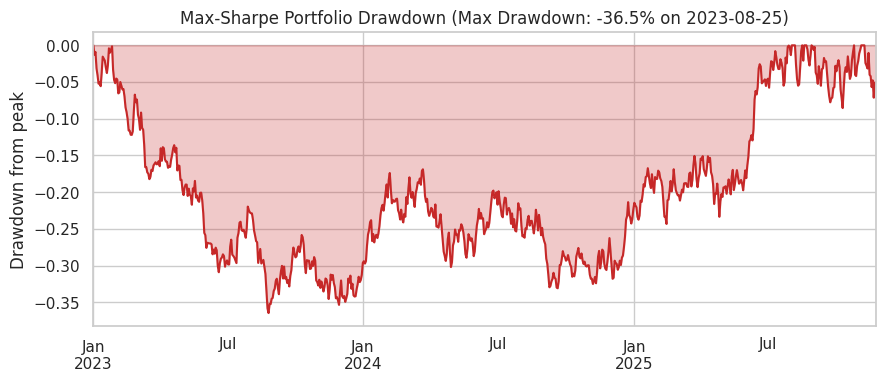

In [13]:
cum = (1 + port_series).cumprod()
running_max = cum.cummax()
drawdown = cum / running_max - 1
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

fig, ax = plt.subplots(figsize=(9,4))
drawdown.plot(ax=ax, color="#C62828")
ax.fill_between(drawdown.index, drawdown.values, 0, color="#C62828", alpha=0.25)
ax.set_title(f"Max-Sharpe Portfolio Drawdown (Max Drawdown: {max_dd:.1%} on {max_dd_date.date()})")
ax.set_ylabel("Drawdown from peak")
plt.tight_layout()
plt.savefig("outputs/05_drawdown.png")
plt.show()

print(f"Maximum drawdown: {max_dd:.2%} reached on {max_dd_date.date()}")
calmar = (port_series.mean()*252) / abs(max_dd)
print(f"Calmar ratio (annual return / max drawdown): {calmar:.2f}")

## 8. Stress Test — Correlation Shock Scenario

In real crises, cross-asset correlations spike toward 1 as diversification "breaks down" when it is needed most.
We re-run VaR after moving every pairwise correlation 50% of the way toward 1.0 while holding individual asset
volatilities fixed. This quantifies how much the Max-Sharpe portfolio's tail risk is understated in a crisis.

Base-case annualized volatility:    25.01%  -> 95% 1-day VaR: \$259,119
Correlation-shock annualized vol:   28.48%  -> 95% 1-day VaR: \$295,093
VaR increase under stress: 13.9%


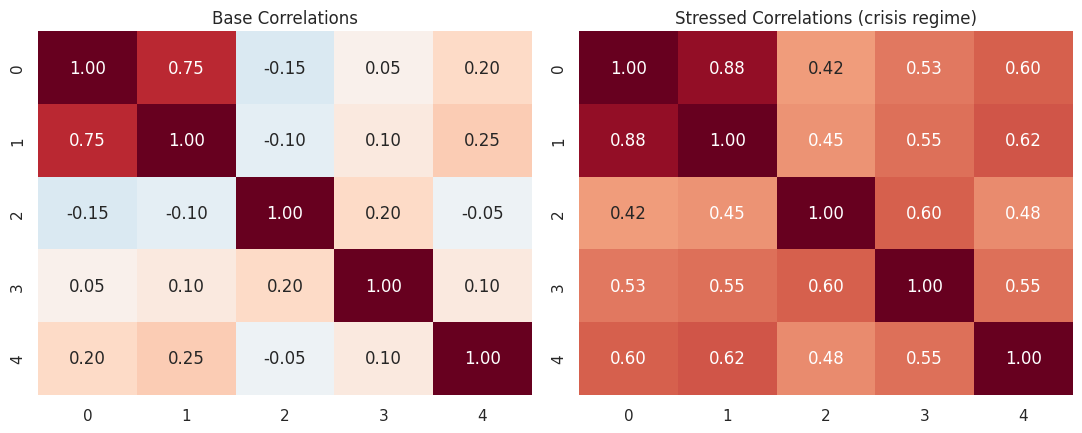

In [14]:
shocked_corr = corr + 0.5 * (1 - corr)
np.fill_diagonal(shocked_corr, 1.0)
shocked_cov_ann = np.outer(annual_vol, annual_vol) * shocked_corr

base_vol = np.sqrt(w_max_sharpe @ cov_ann @ w_max_sharpe)
shocked_vol = np.sqrt(w_max_sharpe @ shocked_cov_ann @ w_max_sharpe)

from scipy.stats import norm
z95 = norm.ppf(0.95)
base_var95_1d = z95 * base_vol / np.sqrt(252)
shocked_var95_1d = z95 * shocked_vol / np.sqrt(252)

print(f"Base-case annualized volatility:    {base_vol:.2%}  -> 95% 1-day VaR: \${base_var95_1d*port_value:,.0f}")
print(f"Correlation-shock annualized vol:   {shocked_vol:.2%}  -> 95% 1-day VaR: \${shocked_var95_1d*port_value:,.0f}")
print(f"VaR increase under stress: {(shocked_var95_1d/base_var95_1d - 1):.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11,4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[0], cbar=False)
ax[0].set_title("Base Correlations")
sns.heatmap(shocked_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1], cbar=False)
ax[1].set_title("Stressed Correlations (crisis regime)")
plt.tight_layout()
plt.savefig("outputs/06_stress_test.png")
plt.show()

## 9. Key Findings & Recommendations

**Findings**
1. Naive, unconstrained mean-variance optimization concentrated the entire portfolio in Bitcoin. This illustrates
   why raw Markowitz output should not be deployed without position limits or a shrinkage estimator. The position-capped
   (35%) max-Sharpe portfolio still meaningfully outperforms the naive equal-weight allocation on a risk-adjusted
   basis while remaining investable for an investment committee.
2. Historical, parametric, and Monte Carlo VaR estimates are closely aligned at the 95% confidence level. They
   diverge more at 99%, where the parametric method's normal-distribution assumption understates tail risk relative to
   historical simulation. Fat tails matter most where risk limits bind hardest.
3. EWMA-forecast volatility responds faster to recent shocks than the 21-day rolling window. It is therefore the
   more decision-useful figure for setting next-day risk limits.
4. The correlation-shock stress test shows 1-day VaR rising substantially as correlations move toward a crisis
   regime. The portfolio's *measured* diversification benefit is meaningfully overstated relative to what would be
   available during a systemic drawdown.

**Recommendations**
- Adopt the Max-Sharpe weights (or a risk-budgeted blend toward them) over the current equal-weight approach,
  subject to the committee's constraints on minimum bond/gold allocation for liquidity and mandate reasons.
- Report VaR using historical simulation (or a fat-tailed parametric distribution) rather than the normal-parametric
  method for regulatory/internal limit-setting, given the tail-risk understatement observed at 99% confidence.
- Set volatility-based position limits off the EWMA forecast, not the trailing rolling window, so limits tighten
  faster when markets destabilize.
- Hold the correlation-shock stress scenario as a standing quarterly report line item. Size any incremental
  crisis-buffer capital off the *stressed* VaR figure rather than the base-case one.

**Limitations:** Simulated returns are calibrated but not historical; real returns exhibit fat tails, volatility
clustering (GARCH effects), and regime shifts beyond what a single multivariate-normal draw captures. A production
version should refit on actual return history and consider a GARCH or historical-bootstrap simulation engine.
